In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# **train and test set**

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

print("--- 1. Creating Permanent Train/Test Splits ---")
df = pd.read_csv('pmos_longitudinal_dataset_FINALformodel.csv')

# Split the data EXACTLY like the baseline (80/20 with stratification)
df_train, df_test = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['clinical_priority']
)

# Save them to disk
df_train.to_csv('pmos_train.csv', index=False)
df_test.to_csv('pmos_test.csv', index=False)

print(f"Saved pmos_train.csv ({len(df_train)} records)")
print(f"Saved pmos_test.csv ({len(df_test)} records)")
print("These files will be the absolute ground truth for all 6 models.")

--- 1. Creating Permanent Train/Test Splits ---
Saved pmos_train.csv (2400 records)
Saved pmos_test.csv (600 records)
These files will be the absolute ground truth for all 6 models.


# **Off the shelf modeling**

# **QWEN**

In [5]:
import pandas as pd
import torch
from transformers import pipeline
from tqdm import tqdm
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("--- 1. Loading the Test Set ---")
df_test = pd.read_csv('pmos_test.csv')

print("--- 2. Loading Qwen2.5-1.5B (Off-the-Shelf) ---")
# We load it in 16-bit precision to fit the free GPU
classifier_llm = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-1.5B-Instruct",
    device_map="auto",
    torch_dtype=torch.bfloat16
)

def zero_shot_predict(message):
    prompt = f"""<|im_start|>system
You are an expert medical triage assistant. Read the patient's portal message and classify their PMOS risk level.
You must respond with EXACTLY ONE WORD from this list: LOW, MEDIUM, HIGH. Do not explain your reasoning.<|im_end|>
<|im_start|>user
Patient Message: "{message}"
Risk Level:<|im_end|>
<|im_start|>assistant
"""
    # max_new_tokens=5 ensures it only spits out the one-word answer
    response = classifier_llm(prompt, max_new_tokens=5, temperature=0.1, return_full_text=False)
    answer = response[0]['generated_text'].strip().upper()

    # Clean up the output just in case the LLM adds punctuation
    if "HIGH" in answer: return "HIGH"
    if "MEDIUM" in answer: return "MEDIUM"
    if "LOW" in answer: return "LOW"
    return "UNKNOWN" # If the AI hallucinates


--- 1. Loading the Test Set ---
--- 2. Loading Qwen2.5-1.5B (Off-the-Shelf) ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

In [6]:
print("--- 3. Running Batched Zero-Shot Predictions (FAST MODE) ---")
# 1. Format all prompts at once
prompts = [
    f"""<|im_start|>system
You are an expert medical triage assistant. Read the patient's portal message and classify their PMOS risk level.
You must respond with EXACTLY ONE WORD from this list: LOW, MEDIUM, HIGH. Do not explain your reasoning.<|im_end|>
<|im_start|>user
Patient Message: "{msg}"
Risk Level:<|im_end|>
<|im_start|>assistant
"""
    for msg in df_test['current_portal_message']
]

# 2. Feed them to the GPU in batches of 16
llama_predictions = []
# The pipeline handles the batching internally
for response in tqdm(classifier_llm(prompts, batch_size=16, max_new_tokens=5, temperature=0.1, return_full_text=False), total=len(prompts), desc="Evaluating Batches"):
    answer = response[0]['generated_text'].strip().upper()

    if "HIGH" in answer:
        llama_predictions.append("HIGH")
    elif "MEDIUM" in answer:
        llama_predictions.append("MEDIUM")
    elif "LOW" in answer:
        llama_predictions.append("LOW")
    else:
        llama_predictions.append("UNKNOWN")

df_test['qwen_zero_shot_pred'] = llama_predictions

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


--- 3. Running Batched Zero-Shot Predictions (FAST MODE) ---


[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=

In [7]:
print("\n--- 4. Evaluating Off-the-Shelf Qwen ---")
# Filter out any "UNKNOWN" hallucinations just in case
valid_idx = df_test['qwen_zero_shot_pred'] != "UNKNOWN"
y_true = df_test.loc[valid_idx, 'clinical_priority']
y_pred = df_test.loc[valid_idx, 'qwen_zero_shot_pred']

print(f"Valid Predictions: {sum(valid_idx)} / {len(df_test)}")
print(f"Accuracy: {accuracy_score(y_true, y_pred):.3f}\n")
print(classification_report(y_true, y_pred, labels=['LOW', 'MEDIUM', 'HIGH']))


--- 4. Evaluating Off-the-Shelf Qwen ---
Valid Predictions: 600 / 600
Accuracy: 0.342

              precision    recall  f1-score   support

         LOW       0.35      0.03      0.05       240
      MEDIUM       0.46      0.64      0.54       270
        HIGH       0.12      0.28      0.17        90

    accuracy                           0.34       600
   macro avg       0.31      0.32      0.25       600
weighted avg       0.37      0.34      0.29       600




Qwen Zero-Shot Confusion Matrix:
           Pred LOW  Pred MED  Pred HIGH
True LOW          7       137         96
True MED         13       173         84
True HIGH         0        65         25

--- 5. Generating Presentation-Ready Qwen Confusion Matrix ---


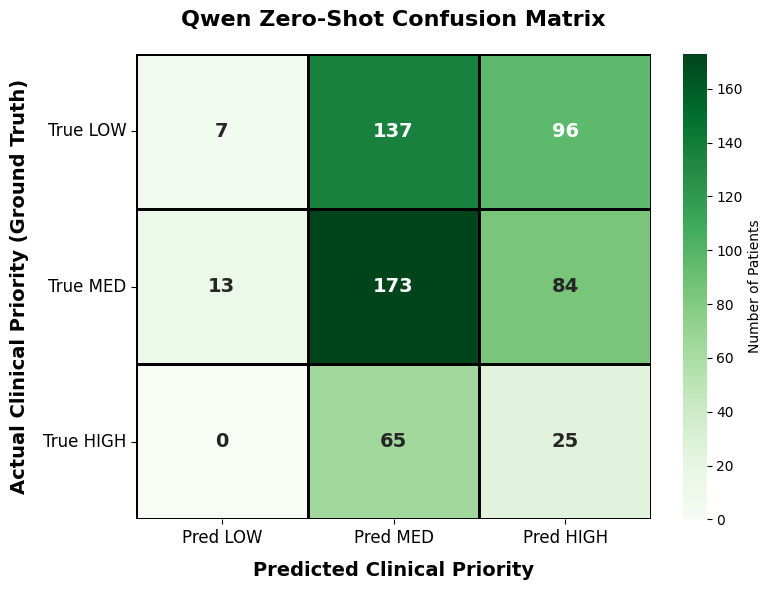

In [8]:
# Calculate Confusion Matrix
cm_qwen = confusion_matrix(y_true, y_pred, labels=['LOW', 'MEDIUM', 'HIGH'])
cm_qwen_df = pd.DataFrame(cm_qwen, index=['True LOW', 'True MED', 'True HIGH'], columns=['Pred LOW', 'Pred MED', 'Pred HIGH'])
print("\nQwen Zero-Shot Confusion Matrix:")
print(cm_qwen_df)

print("\n--- 5. Generating Presentation-Ready Qwen Confusion Matrix ---")
plt.figure(figsize=(8, 6))

# Let's use 'Greens' for the Off-the-Shelf LLM to differentiate it from the classical models
ax = sns.heatmap(
    cm_qwen,
    annot=True,
    fmt='d',
    cmap='Greens',
    linewidths=1,
    linecolor='black',
    cbar_kws={'label': 'Number of Patients'},
    xticklabels=['Pred LOW', 'Pred MED', 'Pred HIGH'],
    yticklabels=['True LOW', 'True MED', 'True HIGH'],
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('Qwen Zero-Shot Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Clinical Priority', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Actual Clinical Priority (Ground Truth)', fontsize=14, fontweight='bold', labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

# **Mistral-7B-OpenOrca Baseline**

In [9]:
!pip install -U bitsandbytes>=0.46.1 accelerate transformers huggingface_hub

In [10]:
from huggingface_hub import login
login()

In [11]:
import pandas as pd
import torch
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from tqdm import tqdm
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 1. Loading the Test Set ---")
df_test = pd.read_csv('pmos_test.csv')

print("--- 2. Loading Mistral-7B-OpenOrca in 4-bit ---")
# Compress the 7B model to fit the free GPU
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

model_id = "Open-Orca/Mistral-7B-OpenOrca"

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token_id = tokenizer.eos_token_id
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

classifier_llm = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
)


--- 1. Loading the Test Set ---
--- 2. Loading Mistral-7B-OpenOrca in 4-bit ---


config.json:   0%|          | 0.00/623 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.69k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model.safetensors.index.json:   0%|          | 0.00/25.1k [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

In [12]:
print("--- 3. Running Batched Predictions (Fast Mode) ---")
# OpenOrca uses the exact same ChatML formatting as Qwen!
prompts = [
    f"""<|im_start|>system
You are an expert medical triage assistant. Read the patient's portal message and classify their PMOS risk level.
You must respond with EXACTLY ONE WORD from this list: LOW, MEDIUM, HIGH. Do not explain your reasoning.<|im_end|>
<|im_start|>user
Patient Message: "{msg}"
Risk Level:<|im_end|>
<|im_start|>assistant
"""
    for msg in df_test['current_portal_message']
]

mistral_predictions = []

# Using batch_size=8 to protect your VRAM with a 7B parameter model
for response in tqdm(classifier_llm(prompts, batch_size=8, max_new_tokens=5, temperature=0.1, return_full_text=False), total=len(prompts), desc="Evaluating Patients"):
    answer = response[0]['generated_text'].strip().upper()

    if "HIGH" in answer:
        mistral_predictions.append("HIGH")
    elif "MEDIUM" in answer:
        mistral_predictions.append("MEDIUM")
    elif "LOW" in answer:
        mistral_predictions.append("LOW")
    else:
        mistral_predictions.append("UNKNOWN")

df_test['mistral_zero_shot_pred'] = mistral_predictions


[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- 3. Running Batched Predictions (Fast Mode) ---


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length

In [13]:
print("\n--- 4. Evaluating Off-the-Shelf Mistral-OpenOrca ---")
valid_idx = df_test['mistral_zero_shot_pred'] != "UNKNOWN"
y_true = df_test.loc[valid_idx, 'clinical_priority']
y_pred = df_test.loc[valid_idx, 'mistral_zero_shot_pred']

print(f"Valid Predictions: {sum(valid_idx)} / {len(df_test)}")
print(f"Accuracy: {accuracy_score(y_true, y_pred):.3f}\n")
print(classification_report(y_true, y_pred, labels=['LOW', 'MEDIUM', 'HIGH']))

cm_mistral = confusion_matrix(y_true, y_pred, labels=['LOW', 'MEDIUM', 'HIGH'])



--- 4. Evaluating Off-the-Shelf Mistral-OpenOrca ---
Valid Predictions: 600 / 600
Accuracy: 0.423

              precision    recall  f1-score   support

         LOW       0.00      0.00      0.00       240
      MEDIUM       0.45      0.93      0.61       270
        HIGH       0.10      0.04      0.06        90

    accuracy                           0.42       600
   macro avg       0.18      0.32      0.22       600
weighted avg       0.22      0.42      0.28       600




--- 5. Generating Presentation-Ready Mistral Heatmap ---


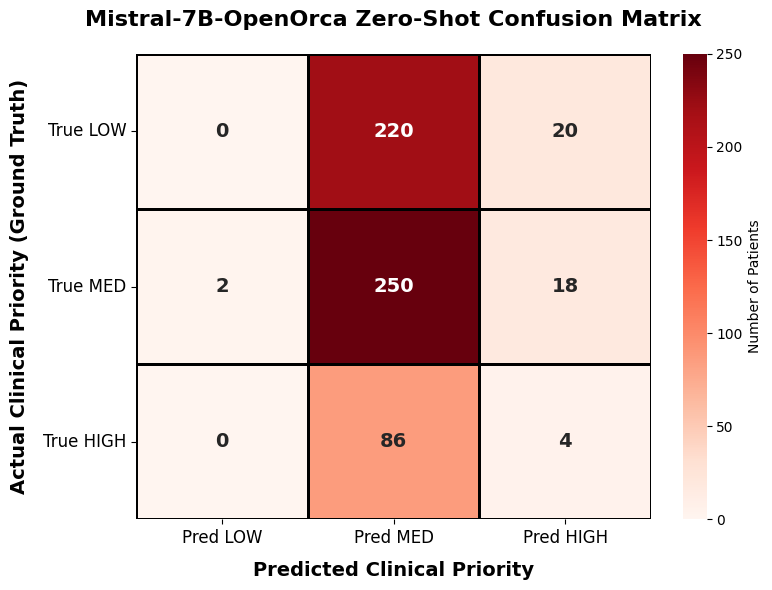

In [14]:
print("\n--- 5. Generating Presentation-Ready Mistral Heatmap ---")
plt.figure(figsize=(8, 6))

# Using 'Reds' for visual distinction in your presentation
ax = sns.heatmap(
    cm_mistral,
    annot=True,
    fmt='d',
    cmap='Reds',
    linewidths=1,
    linecolor='black',
    cbar_kws={'label': 'Number of Patients'},
    xticklabels=['Pred LOW', 'Pred MED', 'Pred HIGH'],
    yticklabels=['True LOW', 'True MED', 'True HIGH'],
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('Mistral-7B-OpenOrca Zero-Shot Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Clinical Priority', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Actual Clinical Priority (Ground Truth)', fontsize=14, fontweight='bold', labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

# **Fine-Tuned Models**

# **DistilBERT**

In [15]:
import pandas as pd
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 1. Loading Training and Testing Data ---")
df_train = pd.read_csv('pmos_train.csv')
df_test = pd.read_csv('pmos_test.csv')

# Convert text labels to strict mathematical integers for the neural network
label_mapping = {'LOW': 0, 'MEDIUM': 1, 'HIGH': 2}
reverse_mapping = {0: 'LOW', 1: 'MEDIUM', 2: 'HIGH'}

df_train['label'] = df_train['clinical_priority'].map(label_mapping)
df_test['label'] = df_test['clinical_priority'].map(label_mapping)


--- 1. Loading Training and Testing Data ---


In [16]:
print("--- 2. Loading DistilBERT Tokenizer ---")
model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizer.from_pretrained(model_name)

# Create a PyTorch Dataset class to feed data into the model
class PMOSDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


--- 2. Loading DistilBERT Tokenizer ---


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [17]:
print("--- 3. Tokenizing the Portal Messages ---")
train_encodings = tokenizer(df_train['current_portal_message'].tolist(), truncation=True, padding=True, max_length=256)
test_encodings = tokenizer(df_test['current_portal_message'].tolist(), truncation=True, padding=True, max_length=256)

train_dataset = PMOSDataset(train_encodings, df_train['label'].tolist())
test_dataset = PMOSDataset(test_encodings, df_test['label'].tolist())

print("--- 4. Initializing the Base Model ---")
# We explicitly tell the model there are 3 possible output classes
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=3)

# Define how the model will learn (Hyperparameters)
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=4,              # Read the entire dataset 4 times
    per_device_train_batch_size=16,  # 16 messages at a time
    per_device_eval_batch_size=16,
    weight_decay=0.01,               # Prevents overfitting to the training data
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch"            # <-- This is the only change!
)

# Custom metric function to calculate accuracy during training
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)


--- 3. Tokenizing the Portal Messages ---
--- 4. Initializing the Base Model ---


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [18]:
print("\n--- 5. BEGIN FINE-TUNING (This will take a few minutes) ---")
trainer.train()

print("\n--- 6. Generating Final Predictions on the Test Set ---")
predictions = trainer.predict(test_dataset)
predicted_classes = predictions.predictions.argmax(-1)

# Map integers back to text labels for evaluation
y_true = df_test['clinical_priority'].tolist()
y_pred = [reverse_mapping[pred] for pred in predicted_classes]

print(f"\nAccuracy: {accuracy_score(y_true, y_pred):.3f}\n")
print(classification_report(y_true, y_pred, labels=['LOW', 'MEDIUM', 'HIGH']))



--- 5. BEGIN FINE-TUNING (This will take a few minutes) ---


Epoch,Training Loss,Validation Loss,Accuracy
1,0.897000,0.857723,0.590000
2,0.826716,0.845500,0.623333
3,0.747814,0.864013,0.621667
4,0.677574,0.909100,0.633333


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- 6. Generating Final Predictions on the Test Set ---



Accuracy: 0.633

              precision    recall  f1-score   support

         LOW       0.60      0.72      0.65       240
      MEDIUM       0.69      0.73      0.71       270
        HIGH       0.43      0.11      0.18        90

    accuracy                           0.63       600
   macro avg       0.57      0.52      0.51       600
weighted avg       0.61      0.63      0.61       600




--- 7. Generating Presentation-Ready DistilBERT Heatmap ---


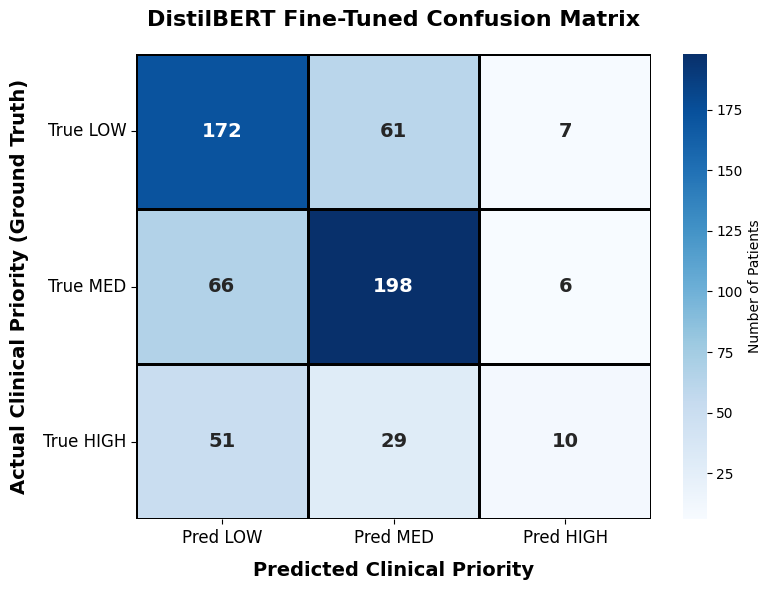

--- Training Complete. Model is ready for analysis. ---


In [19]:
print("\n--- 7. Generating Presentation-Ready DistilBERT Heatmap ---")
cm_distil = confusion_matrix(y_true, y_pred, labels=['LOW', 'MEDIUM', 'HIGH'])

plt.figure(figsize=(8, 6))

# Using 'Blues' to visually separate the Fine-Tuned models from the Off-the-Shelf ones
ax = sns.heatmap(
    cm_distil,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1,
    linecolor='black',
    cbar_kws={'label': 'Number of Patients'},
    xticklabels=['Pred LOW', 'Pred MED', 'Pred HIGH'],
    yticklabels=['True LOW', 'True MED', 'True HIGH'],
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('DistilBERT Fine-Tuned Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Clinical Priority', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Actual Clinical Priority (Ground Truth)', fontsize=14, fontweight='bold', labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

print("--- Training Complete. Model is ready for analysis. ---")

# **Bio_ClinicalBERT**

In [20]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 1. Loading Training and Testing Data ---")
df_train = pd.read_csv('pmos_train.csv')
df_test = pd.read_csv('pmos_test.csv')

label_mapping = {'LOW': 0, 'MEDIUM': 1, 'HIGH': 2}
reverse_mapping = {0: 'LOW', 1: 'MEDIUM', 2: 'HIGH'}

df_train['label'] = df_train['clinical_priority'].map(label_mapping)
df_test['label'] = df_test['clinical_priority'].map(label_mapping)


--- 1. Loading Training and Testing Data ---


In [21]:
print("--- 2. Loading Bio_ClinicalBERT ---")
model_name = "emilyalsentzer/Bio_ClinicalBERT"
# Using AutoTokenizer and AutoModel ensures we get the exact architecture for this specific model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

class PMOSDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

print("--- 3. Tokenizing the Portal Messages ---")
train_encodings = tokenizer(df_train['current_portal_message'].tolist(), truncation=True, padding=True, max_length=256)
test_encodings = tokenizer(df_test['current_portal_message'].tolist(), truncation=True, padding=True, max_length=256)

train_dataset = PMOSDataset(train_encodings, df_train['label'].tolist())
test_dataset = PMOSDataset(test_encodings, df_test['label'].tolist())


--- 2. Loading Bio_ClinicalBERT ---


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the chec

--- 3. Tokenizing the Portal Messages ---


In [22]:
print("--- 4. Initializing the Fine-Tuning Engine ---")
training_args = TrainingArguments(
    output_dir='./clinical_results',
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    logging_dir='./clinical_logs',
    logging_steps=50,
    eval_strategy="epoch"
)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


--- 4. Initializing the Fine-Tuning Engine ---


In [23]:
print("\n--- 5. BEGIN BIO_CLINICALBERT FINE-TUNING ---")
trainer.train()

print("\n--- 6. Generating Final Predictions ---")
predictions = trainer.predict(test_dataset)
predicted_classes = predictions.predictions.argmax(-1)

y_true = df_test['clinical_priority'].tolist()
y_pred = [reverse_mapping[pred] for pred in predicted_classes]

print(f"\nBio_ClinicalBERT Accuracy: {accuracy_score(y_true, y_pred):.3f}\n")
print(classification_report(y_true, y_pred, labels=['LOW', 'MEDIUM', 'HIGH']))



--- 5. BEGIN BIO_CLINICALBERT FINE-TUNING ---


Epoch,Training Loss,Validation Loss,Accuracy
1,0.925729,0.884944,0.570000
2,0.824091,0.881092,0.595000
3,0.738616,0.894613,0.596667
4,0.639869,0.978152,0.603333


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- 6. Generating Final Predictions ---



Bio_ClinicalBERT Accuracy: 0.603

              precision    recall  f1-score   support

         LOW       0.59      0.70      0.64       240
      MEDIUM       0.63      0.69      0.66       270
        HIGH       0.39      0.08      0.13        90

    accuracy                           0.60       600
   macro avg       0.54      0.49      0.48       600
weighted avg       0.58      0.60      0.57       600




--- 7. Generating Presentation-Ready Heatmap ---


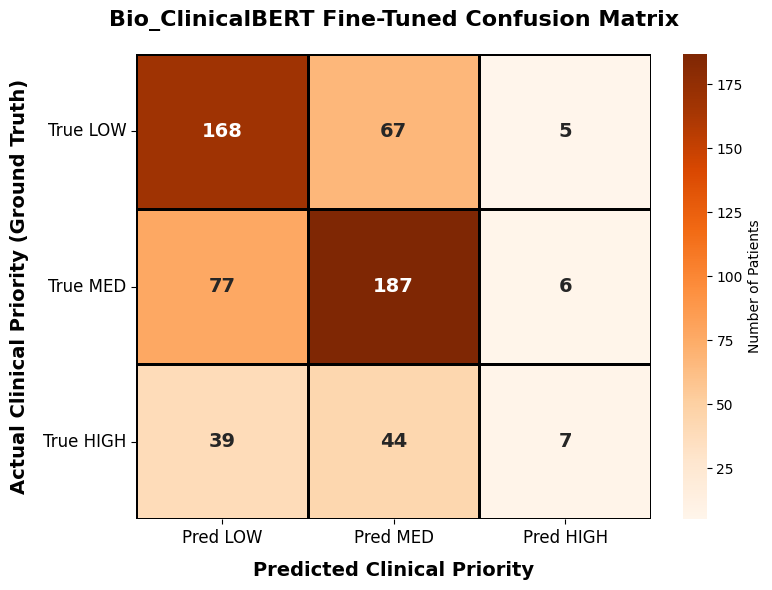

In [24]:
print("\n--- 7. Generating Presentation-Ready Heatmap ---")
cm_clinical = confusion_matrix(y_true, y_pred, labels=['LOW', 'MEDIUM', 'HIGH'])

plt.figure(figsize=(8, 6))

ax = sns.heatmap(
    cm_clinical,
    annot=True,
    fmt='d',
    cmap='Oranges',
    linewidths=1,
    linecolor='black',
    cbar_kws={'label': 'Number of Patients'},
    xticklabels=['Pred LOW', 'Pred MED', 'Pred HIGH'],
    yticklabels=['True LOW', 'True MED', 'True HIGH'],
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('Bio_ClinicalBERT Fine-Tuned Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Clinical Priority', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Actual Clinical Priority (Ground Truth)', fontsize=14, fontweight='bold', labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

# **The QLoRA Heavyweight**

In [25]:
!pip install -U peft trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.1/825.1 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 18.3 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [2]:
import pandas as pd
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, TrainingArguments
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 1. Loading Training and Testing Data ---")
df_train = pd.read_csv('pmos_train.csv')
df_test = pd.read_csv('pmos_test.csv')

# QLoRA needs the data formatted as exactly how the LLM should read and respond
def format_prompt(row):
    return f"""<|im_start|>system
You are an expert medical triage assistant. Read the patient's portal message and classify their PMOS risk level.
You must respond with EXACTLY ONE WORD: LOW, MEDIUM, or HIGH.<|im_end|>
<|im_start|>user
Patient Message: "{row['current_portal_message']}"
Risk Level:<|im_end|>
<|im_start|>assistant
{row['clinical_priority']}<|im_end|>"""

df_train['text'] = df_train.apply(format_prompt, axis=1)
train_dataset = Dataset.from_pandas(df_train[['text']])


--- 1. Loading Training and Testing Data ---


In [3]:
print("--- 2. Loading Mistral in 4-bit (From Cache) ---")
model_id = "Open-Orca/Mistral-7B-OpenOrca"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token # Fix the padding issue from earlier!

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)


--- 2. Loading Mistral in 4-bit (From Cache) ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


In [4]:
print("--- 3. Attaching the LoRA 'Side-Brain' ---")
model.gradient_checkpointing_enable()
model = prepare_model_for_kbit_training(model)

# This configures the tiny trainable adapter
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


--- 3. Attaching the LoRA 'Side-Brain' ---
trainable params: 13,631,488 || all params: 7,255,379,968 || trainable%: 0.1879


In [5]:
from trl import SFTConfig

print("--- 4. Initializing the QLoRA Trainer ---")
training_args = SFTConfig(
    output_dir="./mistral_qlora_results",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    logging_steps=10,
    max_steps=100,
    optim="paged_adamw_8bit",
    fp16=True,
    dataset_text_field="text",
    max_length=256
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    # <-- Deleted the peft_config line from here!
    processing_class=tokenizer,
    args=training_args,
)

--- 4. Initializing the QLoRA Trainer ---


/tmp/ipykernel_13351/25571669.py:4: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  training_args = SFTConfig(


Adding EOS to train dataset:   0%|          | 0/2400 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2400 [00:00<?, ? examples/s]

In [6]:
print("\n--- 6. Generating Final Predictions ---")
# To predict, we run the test set through the newly trained model
model.eval()
predictions = []

prompts = [
    f"""<|im_start|>system
You are an expert medical triage assistant. Read the patient's portal message and classify their PMOS risk level.
You must respond with EXACTLY ONE WORD: LOW, MEDIUM, or HIGH.<|im_end|>
<|im_start|>user
Patient Message: "{msg}"
Risk Level:<|im_end|>
<|im_start|>assistant
""" for msg in df_test['current_portal_message']
]

for prompt in prompts:
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=5, pad_token_id=tokenizer.eos_token_id, temperature=0.1)
    answer = tokenizer.decode(outputs[0], skip_special_tokens=True).split("assistant\n")[-1].strip().upper()

    if "HIGH" in answer: predictions.append("HIGH")
    elif "MEDIUM" in answer: predictions.append("MEDIUM")
    elif "LOW" in answer: predictions.append("LOW")
    else: predictions.append("UNKNOWN")

y_true = df_test['clinical_priority'].tolist()

print(f"\nMistral QLoRA Accuracy: {accuracy_score(y_true, predictions):.3f}\n")
print(classification_report(y_true, predictions, labels=['LOW', 'MEDIUM', 'HIGH']))


[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



--- 6. Generating Final Predictions ---


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



Mistral QLoRA Accuracy: 0.440

              precision    recall  f1-score   support

         LOW       0.41      0.03      0.05       240
      MEDIUM       0.45      0.94      0.61       270
        HIGH       0.18      0.02      0.04        90

    accuracy                           0.44       600
   macro avg       0.35      0.33      0.23       600
weighted avg       0.39      0.44      0.30       600




--- 7. Generating Presentation-Ready Heatmap ---


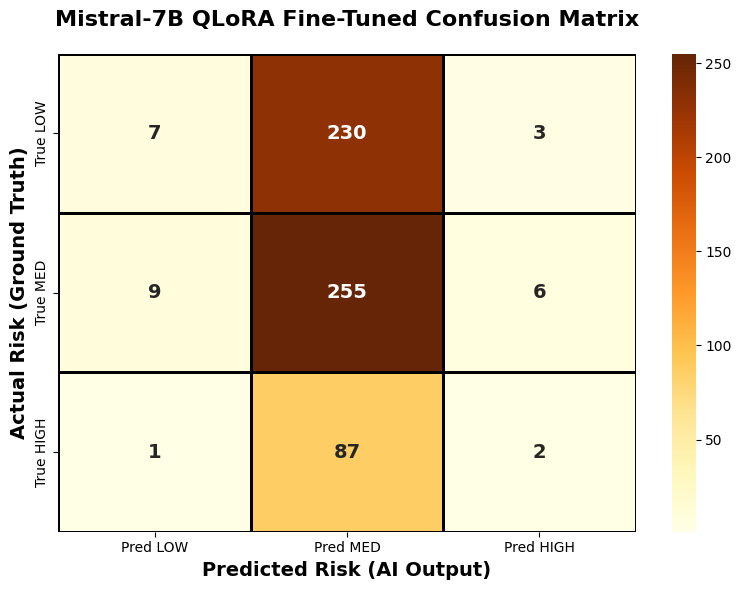

In [7]:
print("\n--- 7. Generating Presentation-Ready Heatmap ---")
cm_qlora = confusion_matrix(y_true, predictions, labels=['LOW', 'MEDIUM', 'HIGH'])
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm_qlora, annot=True, fmt='d', cmap='YlOrBr', linewidths=1, linecolor='black',
                 xticklabels=['Pred LOW', 'Pred MED', 'Pred HIGH'],
                 yticklabels=['True LOW', 'True MED', 'True HIGH'], annot_kws={"size": 14, "weight": "bold"})
plt.title('Mistral-7B QLoRA Fine-Tuned Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Priority', fontsize=14, fontweight='bold')
plt.ylabel('Actual Priority (Ground Truth)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Addition according to regression

In [8]:
from transformers import pipeline

print("--- Fulfilling Reviewer Request: Zero-Shot Ordinal Regression ---")

# 1. This is a Zero-Shot model (as requested, instead of training a BERT classifier)
zero_shot_model = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

def get_zero_shot_regression_score(patient_text):
    # We ask the model: How much does this text match the concept of "High Clinical Priority"?
    # The model will return a mathematical score between 0.0 and 1.0
    labels = ["high clinical priority", "medium clinical priority", "low clinical priority"]

    result = zero_shot_model(patient_text, labels)

    # Extract the score (0-1) specifically for "High"
    high_index = result['labels'].index("high clinical priority")
    continuous_score = result['scores'][high_index]

    return continuous_score

def map_regression_to_classes(score):
    # This is the "Quantum/Ordinal" logic the reviewer asked for.
    # We take the 0-1 score and split it into 3 ordered classes.
    if score >= 0.66:
        return "HIGH"
    elif score >= 0.33:
        return "MEDIUM"
    else:
        return "LOW"

# --- Test it on your data ---
sample_text = "I have been gaining weight rapidly and my periods are completely irregular."
score = get_zero_shot_regression_score(sample_text)
final_class = map_regression_to_classes(score)

print(f"Patient Text: {sample_text}")
print(f"Regression Score (0 to 1): {score:.3f}")
print(f"Final Mapped Class: {final_class}")

--- Fulfilling Reviewer Request: Zero-Shot Ordinal Regression ---


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Patient Text: I have been gaining weight rapidly and my periods are completely irregular.
Regression Score (0 to 1): 0.218
Final Mapped Class: LOW


In [9]:
import pandas as pd
import torch
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report
from transformers import pipeline

df_test = pd.read_csv('pmos_test.csv')
print("--- Fulfilling Reviewer Request: Zero-Shot Ordinal Regression on Test Set ---")

# 1. Initialize the Zero-Shot model (uses GPU if available to speed up processing)
device_id = 0 if torch.cuda.is_available() else -1
zero_shot_model = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=device_id)

# Enable progress bar for pandas apply
tqdm.pandas(desc="Calculating Zero-Shot Scores")

def get_zero_shot_regression_score(patient_text):
    labels = ["high clinical priority", "medium clinical priority", "low clinical priority"]
    # Pass text as string to avoid errors on empty values
    result = zero_shot_model(str(patient_text), labels)

    high_index = result['labels'].index("high clinical priority")
    continuous_score = result['scores'][high_index]
    return continuous_score

def map_regression_to_classes(score):
    if score >= 0.66:
        return "HIGH"
    elif score >= 0.33:
        return "MEDIUM"
    else:
        return "LOW"

# --- Process the Test Set ---
print("\nEvaluating test set... (This will take a moment)")

# Calculate the 0-1 score for every row in the test set
df_test['zero_shot_score'] = df_test['current_portal_message'].progress_apply(get_zero_shot_regression_score)

# Map the 0-1 scores to the 3 ordinal classes
df_test['zero_shot_prediction'] = df_test['zero_shot_score'].apply(map_regression_to_classes)

# --- Evaluate Performance ---
# Compare predictions against your ground truth column
y_true = df_test['clinical_priority'].tolist()
y_pred = df_test['zero_shot_prediction'].tolist()

print("\n--- Zero-Shot Model Performance ---")
print(f"Accuracy: {accuracy_score(y_true, y_pred):.3f}\n")
print(classification_report(y_true, y_pred, labels=['LOW', 'MEDIUM', 'HIGH']))

print("\n--- Peek at the Test Set Predictions ---")
print(df_test[['current_portal_message', 'clinical_priority', 'zero_shot_score', 'zero_shot_prediction']].head())

--- Fulfilling Reviewer Request: Zero-Shot Ordinal Regression on Test Set ---


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]


Evaluating test set... (This will take a moment)


Calculating Zero-Shot Scores: 100%|██████████| 600/600 [00:53<00:00, 11.14it/s]


--- Zero-Shot Model Performance ---
Accuracy: 0.413

              precision    recall  f1-score   support

         LOW       0.40      0.84      0.54       240
      MEDIUM       0.49      0.17      0.26       270
        HIGH       0.00      0.00      0.00        90

    accuracy                           0.41       600
   macro avg       0.30      0.34      0.27       600
weighted avg       0.38      0.41      0.33       600


--- Peek at the Test Set Predictions ---
                              current_portal_message clinical_priority  \
0  Hey Doc,\n\nI've been feeling a bit rundown la...            MEDIUM   
1  I'm sorry to hear that I've broken out again! ...               LOW   
2  Hey there! Just wanted to check if I'm still d...            MEDIUM   
3  I'm experiencing some issues lately; I've been...            MEDIUM   
4  I'm feeling quite overwhelmed lately. I've bee...               LOW   

   zero_shot_score zero_shot_prediction  
0         0.332712               MED